# Simple Logistic Regression Workbench

This notebook trains a simple logistic regression model on every CSV file in `python/output`, and randomises the row order before splitting.

The current model uses `level_t` and `learn_cnt`. The lag features `a_t_minus_5` to `a_t_minus_1` are defined below and can be enabled later by switching one flag.

## 1. Imports

Only the small set of packages needed for loading data, training the model, and reporting results are imported here.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import numpy as np

## 2. Configuration

The train/test split is fixed at 66/33. The current feature set excludes the lag columns, but they are defined separately so they can be switched on later with one change.

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "output").exists():
            return candidate
        if (candidate / "python" / "output").exists():
            return candidate / "python"
    raise FileNotFoundError("Could not find the python/output folder.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "output"
CSV_FILES = sorted(DATA_DIR.glob("*.csv"))

TARGET_COLUMN = "a_t"
BASE_FEATURE_COLUMNS = ["level_t", "learn_cnt"]
OPTIONAL_LAG_FEATURE_COLUMNS = ["a_t_minus_5", "a_t_minus_4", "a_t_minus_3", "a_t_minus_2", "a_t_minus_1"]
USE_LAG_FEATURES = False
FEATURE_COLUMNS = BASE_FEATURE_COLUMNS + OPTIONAL_LAG_FEATURE_COLUMNS if USE_LAG_FEATURES else BASE_FEATURE_COLUMNS

RANDOM_SEED = 42
TEST_SIZE = 0.33

print(f"Project root: {PROJECT_ROOT}")
print("CSV files:")
for csv_file in CSV_FILES:
    print(f"- {csv_file.name}")

Project root: C:\Users\valdr\source\repos\DissertationRepo\python
CSV files:
- 1000HighPitch.csv
- obs1000LP.csv
- obs1000MP.csv


## 3. Data Loading

Each CSV is loaded, checked for the required columns, and shuffled before the train/test split so the model does not learn from the original row order.

In [3]:
def load_dataset(csv_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path)
    required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
    missing_columns = [column for column in required_columns if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"Missing columns in {csv_path.name}: {', '.join(missing_columns)}")
    return frame[required_columns].sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

datasets = {csv_file.stem: load_dataset(csv_file) for csv_file in CSV_FILES}
for name, frame in datasets.items():
    print(f"{name}: {frame.shape[0]} rows x {frame.shape[1]} columns")
    display(frame.head())

1000HighPitch: 37441 rows x 3 columns


,level_t,learn_cnt,a_t
0,1,0,1
1,3,0,0
2,2,0,0
3,1,0,1
4,3,0,1


obs1000LP: 40554 rows x 3 columns


,level_t,learn_cnt,a_t
0,3,7,0
1,2,8,1
2,1,2,1
3,1,0,1
4,2,4,0


obs1000MP: 36741 rows x 3 columns


,level_t,learn_cnt,a_t
0,3,3,0
1,1,1,1
2,1,1,1
3,1,1,0
4,2,2,1


## 4. Model Training

A single small pipeline is used for every dataset: imputation, scaling, and logistic regression. The split is 66% training and 33% testing.

In [4]:
def build_model() -> Pipeline:
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    )


def train_and_evaluate(frame: pd.DataFrame) -> dict[str, Any]:
    X_train, X_test, y_train, y_test = train_test_split(
        frame[FEATURE_COLUMNS],
        frame[TARGET_COLUMN],
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=frame[TARGET_COLUMN] if frame[TARGET_COLUMN].nunique() > 1 else None,
    )

    model = build_model()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    return {
        "model": model,
        "X_test": X_test.reset_index(drop=True),
        "y_test": y_test.reset_index(drop=True),
        "y_pred": pd.Series(y_pred),
        "metrics": {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        },
    }


def summarize_result(dataset_name: str, frame: pd.DataFrame) -> tuple[dict[str, Any], dict[str, Any]]:
    result = train_and_evaluate(frame)
    return result, {"dataset": dataset_name, "rows": len(frame), **result["metrics"]}


training_results = {}
results_rows = []

for dataset_name, frame in datasets.items():
    result, summary_row = summarize_result(dataset_name, frame)
    training_results[dataset_name] = result
    results_rows.append(summary_row)

results_df = pd.DataFrame(results_rows).sort_values("dataset").reset_index(drop=True)
display(results_df)

,dataset,rows,accuracy,precision,recall,f1_score,specificity,tn,fp,fn,tp
0,1000HighPitch,37441,0.792247,0.792247,1.00000,0.884082,0.000000,0,2567,0,9789
1,obs1000LP,40554,0.567660,0.538392,0.39024,0.452498,0.717475,5206,2050,3736,2391
2,obs1000MP,36741,0.649732,0.649732,1.00000,0.787682,0.000000,0,4247,0,7878


## 5. Results Details

This section prints the most important validation results for each dataset, including the confusion matrix counts and the classification report.

In [5]:
def show_metrics(dataset_name: str, result: dict[str, Any]) -> None:
    metrics = result["metrics"]
    print(f"Dataset: {dataset_name}")
    print(f"TN={metrics['tn']}  FP={metrics['fp']}  FN={metrics['fn']}  TP={metrics['tp']}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 score: {metrics['f1_score']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")
    print(classification_report(result["y_test"], result["y_pred"], zero_division=0))
    print("-" * 60)


for dataset_name, result in training_results.items():
    show_metrics(dataset_name, result)

Dataset: 1000HighPitch
TN=0  FP=2567  FN=0  TP=9789
Accuracy: 0.7922
Precision: 0.7922
Recall: 1.0000
F1 score: 0.8841
Specificity: 0.0000
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2567
           1       0.79      1.00      0.88      9789

    accuracy                           0.79     12356
   macro avg       0.40      0.50      0.44     12356
weighted avg       0.63      0.79      0.70     12356

------------------------------------------------------------
Dataset: obs1000LP
TN=5206  FP=2050  FN=3736  TP=2391
Accuracy: 0.5677
Precision: 0.5384
Recall: 0.3902
F1 score: 0.4525
Specificity: 0.7175
              precision    recall  f1-score   support

           0       0.58      0.72      0.64      7256
           1       0.54      0.39      0.45      6127

    accuracy                           0.57     13383
   macro avg       0.56      0.55      0.55     13383
weighted avg       0.56      0.57      0.56     13383

-----

## 6. Validation data plots

Class plots for learn count against predicted probability

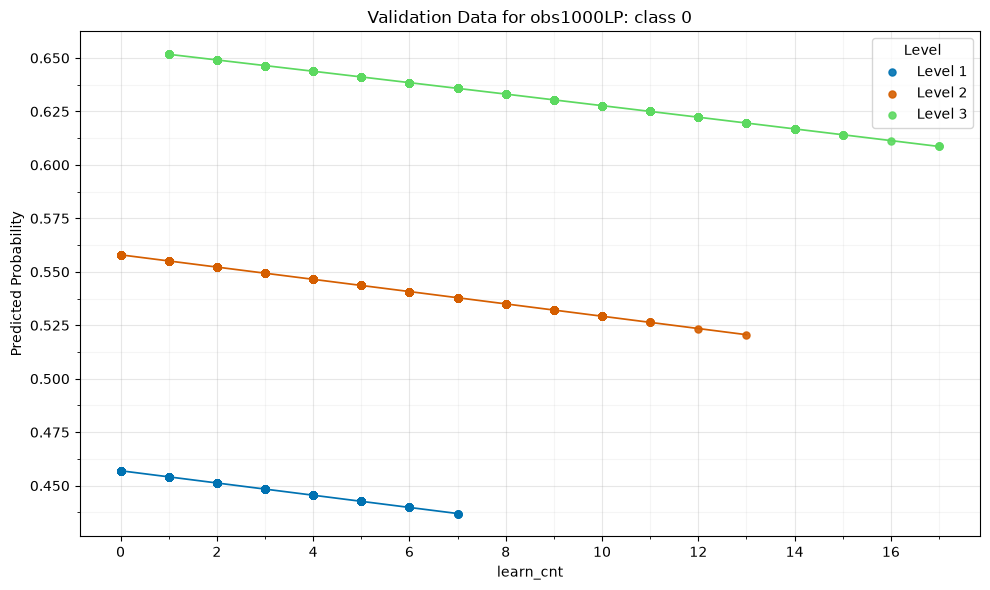

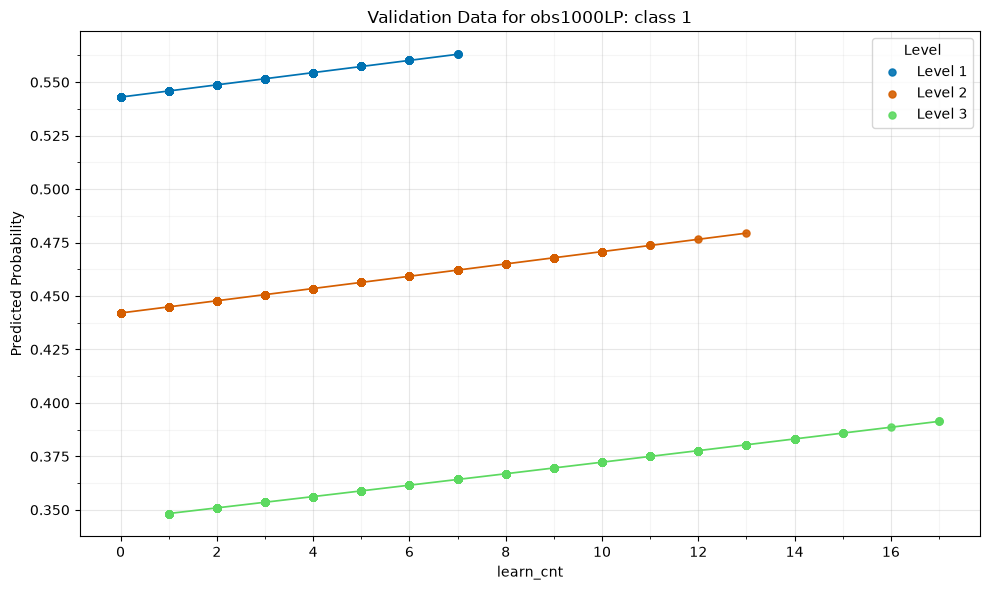

In [6]:
validation_result = training_results["obs1000LP"]

validation_data = validation_result["X_test"].copy()

# Columns: class 0, class 1 probabilities
validation_probabilities = validation_result["model"].predict_proba(validation_data)
validation_data['probability_class_0'] = validation_probabilities[:, 0]
validation_data['probability_class_1'] = validation_probabilities[:, 1]

levels = [1, 2, 3]
colours = {1: "#0072B2", 2: "#D55E00", 3: "#5CD960"}
class_columns = [
    ('probability_class_0', 'Validation Data for obs1000LP: class 0'),
    ('probability_class_1', 'Validation Data for obs1000LP: class 1'),
]

def plot_validation_class(probability_column: str, title: str) -> None:
    # Plot one predicted class at a time so the figure stays simple.
    fig, axis = plt.subplots(figsize=(10, 6))

    for level in levels:
        # Keep only the selected level and the probability column we want to draw.
        level_frame = validation_data.loc[validation_data['level_t'] == level, ['learn_cnt', probability_column]]
        if level_frame.empty:
            continue

        # Sort so the connecting line follows learn_cnt order
        level_frame = level_frame.sort_values('learn_cnt')
        axis.scatter(
            level_frame['learn_cnt'],
            level_frame[probability_column],
            color=colours[level],
            s=26,
            alpha=0.9,
            label=f'Level {level}',
            zorder=3,
        )
        axis.plot(
            level_frame['learn_cnt'],
            level_frame[probability_column],
            color=colours[level],
            linestyle='-',
            linewidth=1.25,
            zorder=2,
        )

    axis.set_xlabel('learn_cnt')
    axis.set_ylabel('Predicted Probability')
    axis.set_title(title)
    axis.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
    axis.xaxis.set_minor_locator(AutoMinorLocator(2))
    axis.yaxis.set_major_locator(MaxNLocator(nbins=10))
    axis.yaxis.set_minor_locator(AutoMinorLocator(2))
    axis.grid(True, which='major', alpha=0.3)
    axis.grid(True, which='minor', alpha=0.12)
    axis.legend(title='Level')
    plt.tight_layout()
    plt.show()

for probability_column, title in class_columns:
    plot_validation_class(probability_column, title)


## 7. Manual Prediction

Use this section to test a single row manually.

In [7]:
example_dataset = results_df.loc[1, "dataset"]
model = training_results[example_dataset]["model"]

custom_input = pd.DataFrame([{
    "level_t": 2,
    "learn_cnt": 7,
    # "a_t_minus_5": 0,
    # "a_t_minus_4": 0,
    # "a_t_minus_3": 0,
    # "a_t_minus_2": 0,
    # "a_t_minus_1": 0,
}])

print(f"Prediction for dataset: {example_dataset}")
display(custom_input)
print(f"Predicted class: {model.predict(custom_input)[0]}")
print(f"Predicted probability of class {model.predict(custom_input)[0]}: {model.predict_proba(custom_input)[0, 1]:.4f}")

Prediction for dataset: obs1000LP


,level_t,learn_cnt
0,2,7


Predicted class: 0
Predicted probability of class 0: 0.4621


## 8. How to Extend the Notebook

To add the lag columns later, change `USE_LAG_FEATURES` to `True`. That will include `a_t_minus_5` to `a_t_minus_1` without changing the rest of the notebook.